In [1]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000067900""","""lymphocyte_count_int""",0.015659,-0.097882,0.097882,-1.0
"""ENSG00000145386""","""mean_corpuscular_haemoglobin_i…",0.000096,-0.059845,0.059845,-1.0
"""ENSG00000164944""","""trunk_predicted_mass_int""",0.015511,-0.04623,0.04623,-1.0
"""ENSG00000107863""","""trunk_predicted_mass_int""",0.033889,-0.122605,0.122605,-1.0
"""ENSG00000121966""","""eosinophill_percentage_int""",0.000392,-0.075765,0.075765,-1.0
…,…,…,…,…,…
"""ENSG00000142208""","""arm_predicted_mass_right_int""",0.009537,-0.049973,0.049973,-1.0
"""ENSG00000101670""","""cholesterol_int""",0.000099,0.035791,0.035791,1.0
"""ENSG00000017427""","""weight_int""",0.000158,-0.170599,0.170599,-1.0


In [3]:
# Configuration and paths
mac = 20
pheno_list_type = None

# Initial the exp assay path variable
exp_anno_local = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_expAssays.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""exp_assays""","""scaled_fitness""","""#66BB6A""","""aPCA fitness""",1
"""exp_assays""","""DMS""","""#66BB6A""","""DMS""",-1
"""exp_assays""","""DMS_score_combined""","""#4DB6AC""","""DMS (combined)""",-1
"""exp_assays""","""LDL_uptake_functional""","""#66BB6A""","""LDL uptake functional""",-1
"""exp_assays""","""LDLR_cell_surface_abundance""","""#81C784""","""LDLR cell surface abundance""",-1
…,…,…,…,…
"""protein_domains""","""low_complexity_domain""","""#FF9933""","""Low Complexity Domain""",1
"""loftee_protein_domains""","""loftee_disorder""","""#E31A1C""","""Disordered Domain""",1
"""loftee_protein_domains""","""loftee_lip""","""#1E90FF""","""Linear Interacting Peptides""",1


In [4]:
gene_id = "ENSG00000106633" # GCK. Gersing et al. A comprehensive map of human glucokinase variant activity. Genome Biol. 2023;24:97.
pheno = 'glycated_haemoglobin_hba1c_int'
assay2plot = 'DMS'

# gene_id = "ENSG00000132170" # PPARG. Majithia et al. Prospective functional classification of all possible missense variants in PPARG. Nat Genet. 2016;48:1570–5.
# pheno = 'hdl_cholesterol_int'
# assay2plot = "DMS"

# gene_id = "ENSG00000171862" # PTEN (DMS_highqual_b). Matreyek et al (2018) Multiplex assessment of protein variant abundance by massively parallel sequencing. Nat Genet 50: 874–882
# pheno = 'igf1_int'
# assay2plot = 'DMS_highqual_b'

# exp_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/experimental_assays"

# exp_anno_filename = "DMS_Marsh_VEP.parquet"
# exp_assay_type_column = 'DMS_assay'
# exp_assay_score_column = 'DMS_score'

# LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"
# !mkdir -p {LOCAL_EXP_DIR}
# !dx download {exp_anno_path}/{exp_anno_filename} -o {LOCAL_EXP_DIR}

# exp_anno_local = f'{LOCAL_EXP_DIR}/{exp_anno_filename}'

# id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']
# exp_anno_df = (
#     pl.read_parquet(exp_anno_local)
#     .filter(pl.col('region')==gene_id)
#     .drop_nulls(subset=id_cols)
#     .pivot(
#         index=id_cols,
#         on=exp_assay_type_column,
#         values=exp_assay_score_column
#     )
# )

# exp_assay_columns = list(set(exp_anno_df.columns) - set(id_cols))
# exp_anno_df = exp_anno_df.select(id_cols + exp_assay_columns)

# exp_anno_df

In [5]:
gene_id = "ENSG00000130164" # LDLR. Roth et al. Science 2025
pheno = 'ldl_direct_int'
assay2plot = 'LDL_uptake_functional'

exp_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/experimental_assays"

exp_anno_filename = "LDLR_Roth_Science_2025.parquet"
exp_assay_type_column = 'assay'
exp_assay_score_column = 'score'

LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"
!mkdir -p {LOCAL_EXP_DIR}
!dx download {exp_anno_path}/{exp_anno_filename} -o {LOCAL_EXP_DIR}

exp_anno_local = f'{LOCAL_EXP_DIR}/{exp_anno_filename}'

id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']
exp_anno_df = (
    pl.read_parquet(exp_anno_local)
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .drop_nulls(subset=id_cols)
    # .select(id_cols + exp_assay_type_columns + exp_assay_score_columns)
    .pivot(
        index=id_cols,
        on=exp_assay_type_column,
        values=exp_assay_score_column
    )
)

exp_assay_columns = list(set(exp_anno_df.columns) - set(id_cols))
exp_assay_columns = ['LDL_uptake_functional', 'LDLR_cell_surface_abundance']

exp_anno_df = exp_anno_df.select(id_cols + exp_assay_columns)

exp_anno_df

Error: path
"/home/dnanexus/data_dir/experimental_assays/LDLR_Roth_Science_2025.parquet"
already exists but -f/--overwrite was not set


/tmp/ipykernel_470200/1210023228.py:20: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


ref_aa,aa_position,alt_aa,region,LDL_uptake_functional,LDLR_cell_surface_abundance
str,i64,str,str,f64,f64
"""G""",2,"""L""","""ENSG00000130164""",-0.042187,0.90099
"""G""",2,"""W""","""ENSG00000130164""",0.985631,1.012781
"""G""",2,"""A""","""ENSG00000130164""",0.964176,1.021534
"""G""",2,"""Y""","""ENSG00000130164""",-0.026747,1.062286
"""G""",2,"""M""","""ENSG00000130164""",1.012579,1.130779
…,…,…,…,…,…
"""G""",343,"""Q""","""ENSG00000130164""",null,null
"""A""",348,"""W""","""ENSG00000130164""",null,null
"""A""",348,"""Y""","""ENSG00000130164""",null,null


In [6]:
gene_trait_df = (
    gene_trait_df
    .filter(
        pl.col('region') == gene_id,
        pl.col('phenotype') == pheno
    )
)

gene_trait_df

region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000130164""","""ldl_direct_int""",3.0392e-14,0.104534,0.104534,1.0


In [7]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Join new annotation if specified above
if exp_anno_local is not None:
    anno = (
        anno
        .filter(
            pl.col('amino_acids').is_not_null(),
            pl.col('amino_acids').str.contains("/"),
            ~pl.col('protein_position').str.contains("-")
        )
        .with_columns(
            pl.col("amino_acids").str.split("/").list.get(0).alias("ref_aa"),
            pl.col("amino_acids").str.split("/").list.get(1).alias("alt_aa"),
            pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
        )

        .join(
            exp_anno_df.lazy(),
            on=['ref_aa', 'aa_position', 'alt_aa', 'region'],
            how='left'
        )

        # Restrict to variants with experimental assay data
        .drop_nulls(exp_assay_columns)
    )


anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        
        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True),
        # (pl.col('consequence_synonymous_variant') == True),

        # Filter for missense variants that we can merge with exp assay data
        # (pl.col('amino_acids').is_not_null()) & (pl.col('amino_acids').str.contains("/")) & (~pl.col('protein_position').str.contains("-")),

        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),
        
        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('mobi_disorder_full') == True),

        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    
)

selected_categories = ['missense', 'genetic_diversity', 'conservation'] # missense
# selected_categories = ['protein_domains'] # protein domains
# selected_categories = ['loftee_protein_domains'] # protein domains
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # synonymous
# selected_categories = ['plof', 'missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # CDS

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

selected_annos = list(set(selected_annos).intersection(set(existing_annos))) + exp_assay_columns
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_470200/787484977.py:79: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_470200/787484977.py:89: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


cadd_raw,am_pathogenicity,region,esmscoremissense,gpn_score,id,verphylop,LDLR_cell_surface_abundance,score_pai3d,LDL_uptake_functional
f32,f32,str,f32,f32,str,f32,f64,f32,f64
1.823055,0.1298,"""ENSG00000130164""",-3.609,-7.25,"""chr19:11102706:G:C""",2.109,0.890469,0.572671,1.047745
5.781151,0.6003,"""ENSG00000130164""",-10.283,-6.8,"""chr19:11102714:C:T""",4.48,0.887659,0.654063,1.004617
4.616593,0.9887,"""ENSG00000130164""",-12.239,-9.17,"""chr19:11102742:A:G""",8.641,1.036775,0.811442,0.938818
3.540323,0.1763,"""ENSG00000130164""",-6.663,-3.01,"""chr19:11102765:G:A""",5.188,1.051302,0.494518,1.00562
1.600276,0.3659,"""ENSG00000130164""",-7.43,-2.04,"""chr19:11100331:C:T""",0.21,0.993115,0.455044,1.001543
…,…,…,…,…,…,…,…,…,…
-0.811778,0.0664,"""ENSG00000130164""",-3.23,-1.08,"""chr19:11123272:C:A""",-2.291,0.583934,0.257193,0.263157
0.140217,0.0834,"""ENSG00000130164""",-3.455,1.16,"""chr19:11123201:A:G""",-0.278,1.008396,0.13645,1.000353
1.087198,0.1032,"""ENSG00000130164""",-5.429,-1.73,"""chr19:11123204:C:T""",0.752,0.983972,0.355996,1.002467


In [8]:
melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
        
    # Keep variants that don't have fillna annotation
    # .join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='semi'
    # )
    
    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr19:11102706:G:C""","""ENSG00000130164""","""am_pathogenicity""",0.1298
"""chr19:11102714:C:T""","""ENSG00000130164""","""am_pathogenicity""",0.6003
"""chr19:11102742:A:G""","""ENSG00000130164""","""am_pathogenicity""",0.9887
"""chr19:11102765:G:A""","""ENSG00000130164""","""am_pathogenicity""",0.1763
"""chr19:11100331:C:T""","""ENSG00000130164""","""am_pathogenicity""",0.3659
…,…,…,…
"""chr19:11123272:C:A""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",0.583934
"""chr19:11123201:A:G""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",1.008396
"""chr19:11123204:C:T""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",0.983972


In [9]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


In [10]:
from scipy.stats import spearmanr, norm

ci_alpha = 0.05
z_crit = norm.ppf(1 - ci_alpha / 2)  # 1.96 for 95% CI

# --- 1. Collect the pre-correlation data ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())

pre_corr_data = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_na' in c]),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df["region", "phenotype"].lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .filter(pl.col('annotation') != 'loftee_hc')
    .collect(engine='streaming')
)

pre_corr_data

id,phenotype,mean_pheno_value,n_individuals,region,annotation,annotation_score
str,str,f32,i32,str,str,f32
"""chr19:11102786:C:T""","""ldl_direct_int""",0.21773,4,"""ENSG00000130164""","""am_pathogenicity""",0.084
"""chr19:11129623:G:A""","""ldl_direct_int""",1.847051,1,"""ENSG00000130164""","""am_pathogenicity""",0.1733
"""chr19:11102786:C:T""","""ldl_direct_int""",0.21773,4,"""ENSG00000130164""","""esmscoremissense""",-4.135
"""chr19:11129623:G:A""","""ldl_direct_int""",1.847051,1,"""ENSG00000130164""","""esmscoremissense""",-10.071
"""chr19:11102786:C:T""","""ldl_direct_int""",0.21773,4,"""ENSG00000130164""","""gpn_score""",-0.94
…,…,…,…,…,…,…
"""chr19:11120488:G:A""","""ldl_direct_int""",0.230201,1,"""ENSG00000130164""","""gpn_score""",-5.15
"""chr19:11129534:T:C""","""ldl_direct_int""",0.124859,7,"""ENSG00000130164""","""gpn_score""",-5.07
"""chr19:11120488:G:A""","""ldl_direct_int""",0.230201,1,"""ENSG00000130164""","""verphylop""",7.84


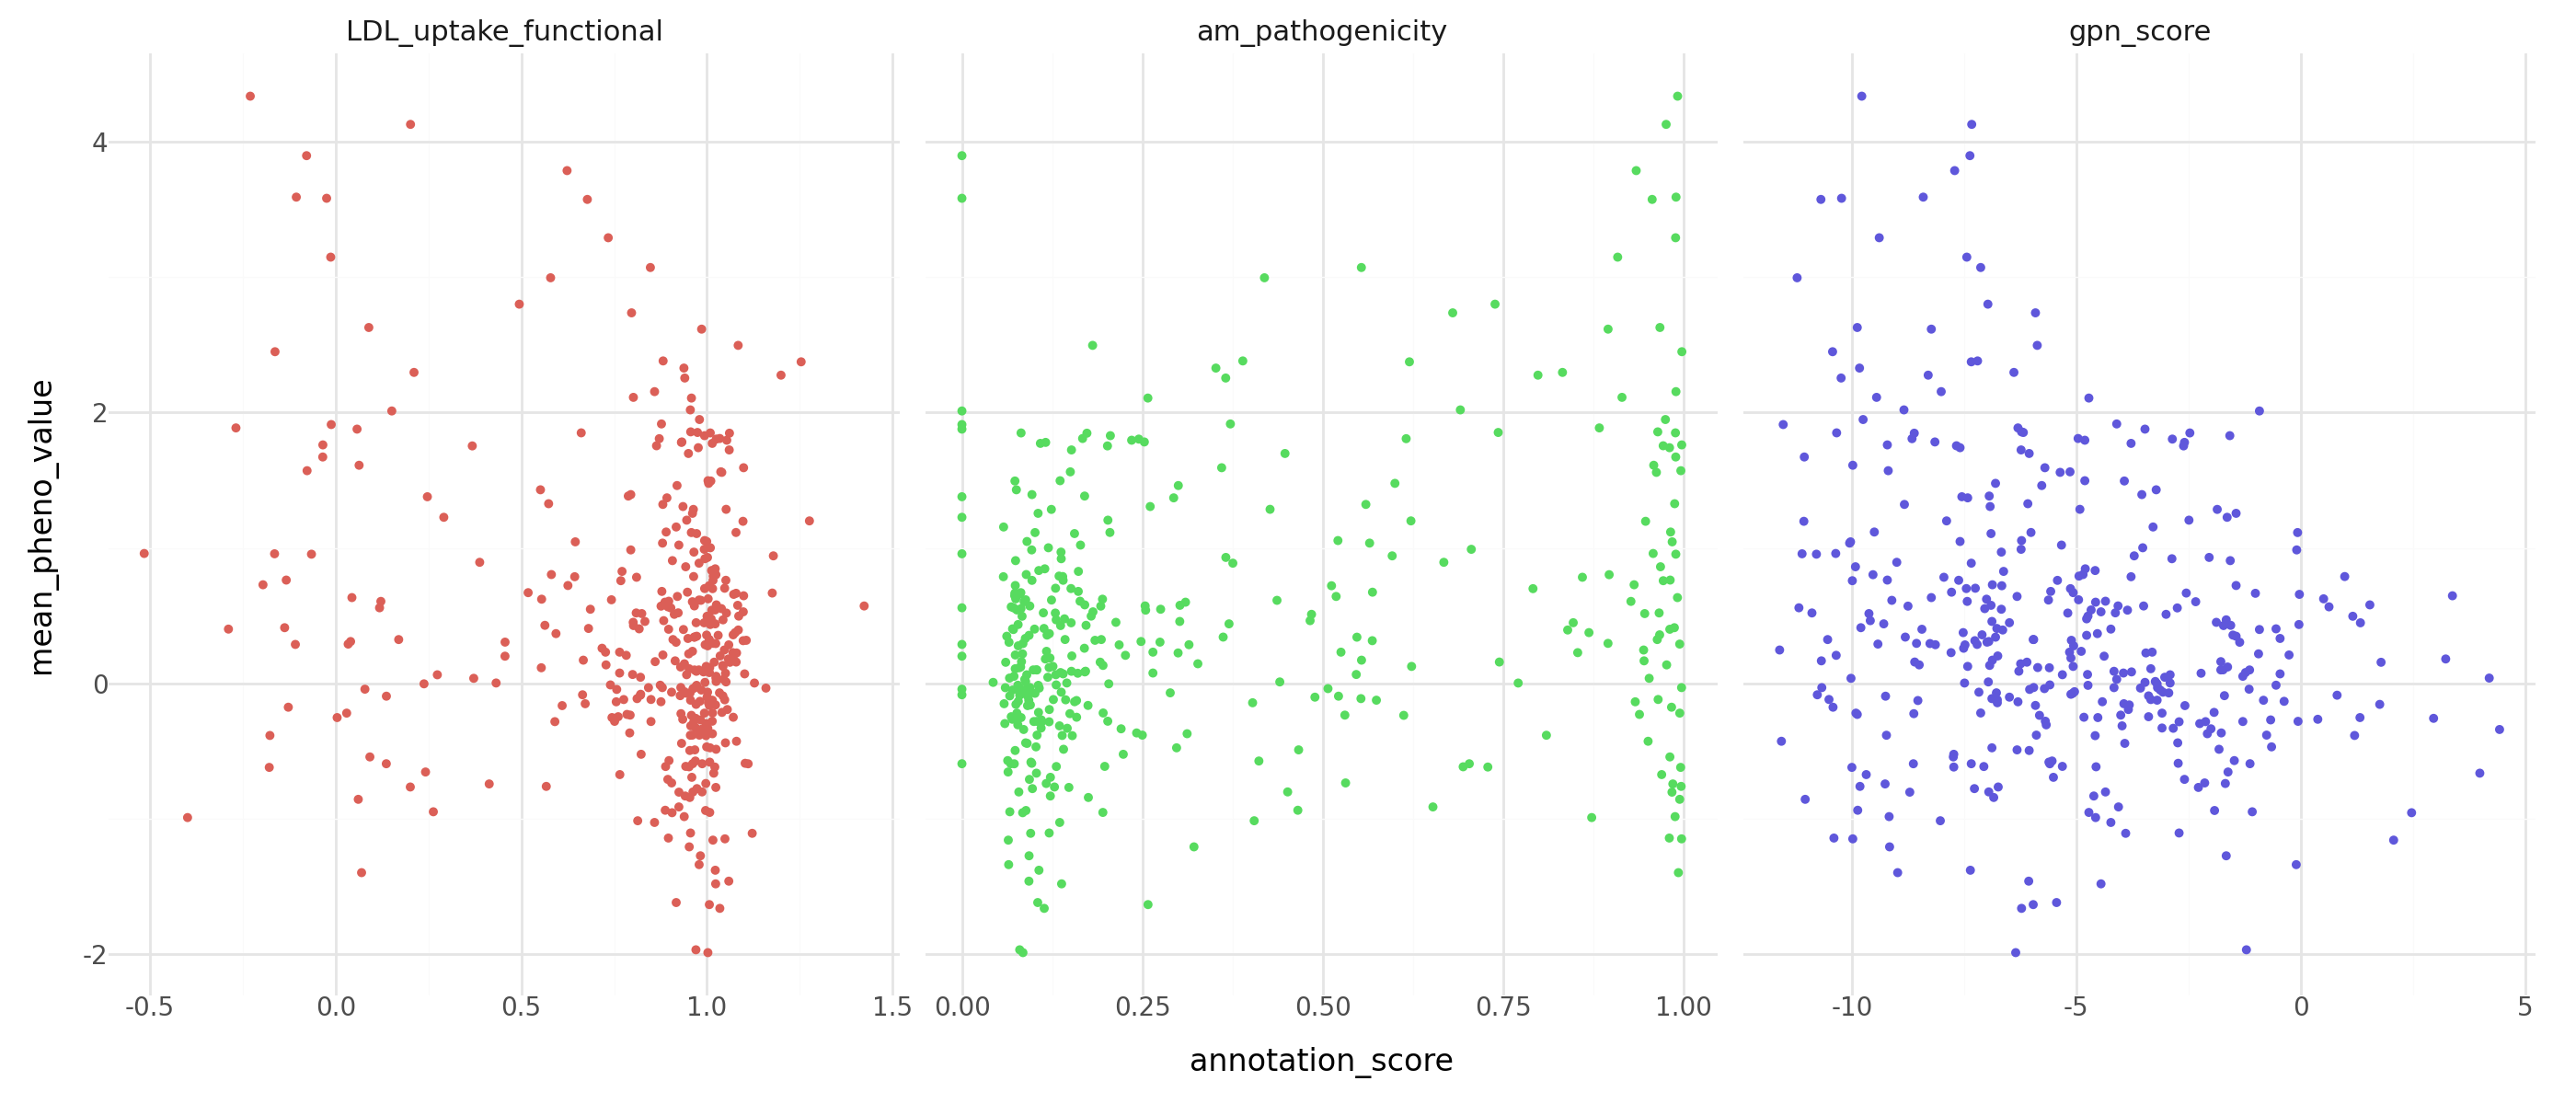

In [11]:
(
    ggplot(
        pre_corr_data.filter(pl.col('annotation').is_in(['phenotype', assay2plot, 'am_pathogenicity', 'gpn_score'])), 
        aes(x='annotation_score', y='mean_pheno_value', color='annotation')
    )
    + geom_point(size=1)
    + facet_wrap("~annotation", nrow=1, scales="free_x")
    + theme_minimal()
    + theme(
        figure_size=(14, 6),
        legend_position="none",
        axis_text=element_text(size=10),
        axis_title=element_text(size=12),
        strip_text=element_text(size=11),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [12]:
anno_df = pre_corr_data[['id', 'region', 'annotation', 'annotation_score']].unique()

pheno_df = (
    pre_corr_data[['id', 'region', 'mean_pheno_value']]
    .unique()
    .rename({'mean_pheno_value': 'annotation_score'})
    .with_columns(
        annotation = pl.lit('phenotype')
    )
    .select(['id', 'region', 'annotation', 'annotation_score'])
)

anno_df = pl.concat([anno_df, pheno_df], how='vertical')

# Get variant ID to amino acid position mapping from the annotation parquet
anno_with_pos = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .filter(
        pl.col('amino_acids').is_not_null(),
        pl.col('amino_acids').str.contains("/"),
        ~pl.col('protein_position').str.contains("-"),
        pl.col('region').is_in(gene_trait_df['region'].unique()),
    )
    .with_columns(
        pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
    )
    .select(['id', 'aa_position'])
    .unique()
    .collect()
)

# Add position to pre_corr_data
anno_df = anno_df.join(anno_with_pos, on='id', how='inner')
anno_df

/tmp/ipykernel_470200/2532201640.py:29: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,aa_position
str,str,str,f32,i64
"""chr19:11123200:G:T""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",-0.234659,723
"""chr19:11102699:G:T""","""ENSG00000130164""","""am_pathogenicity""",0.4827,76
"""chr19:11089615:G:A""","""ENSG00000130164""","""score_pai3d""",0.432398,23
"""chr19:11120106:G:T""","""ENSG00000130164""","""LDL_uptake_functional""",-0.127441,620
"""chr19:11111528:C:T""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",-0.15241,359
…,…,…,…,…
"""chr19:11113325:A:T""","""ENSG00000130164""","""phenotype""",0.826521,412
"""chr19:11107449:T:A""","""ENSG00000130164""","""phenotype""",-0.693927,292
"""chr19:11111619:C:T""","""ENSG00000130164""","""phenotype""",0.527933,389


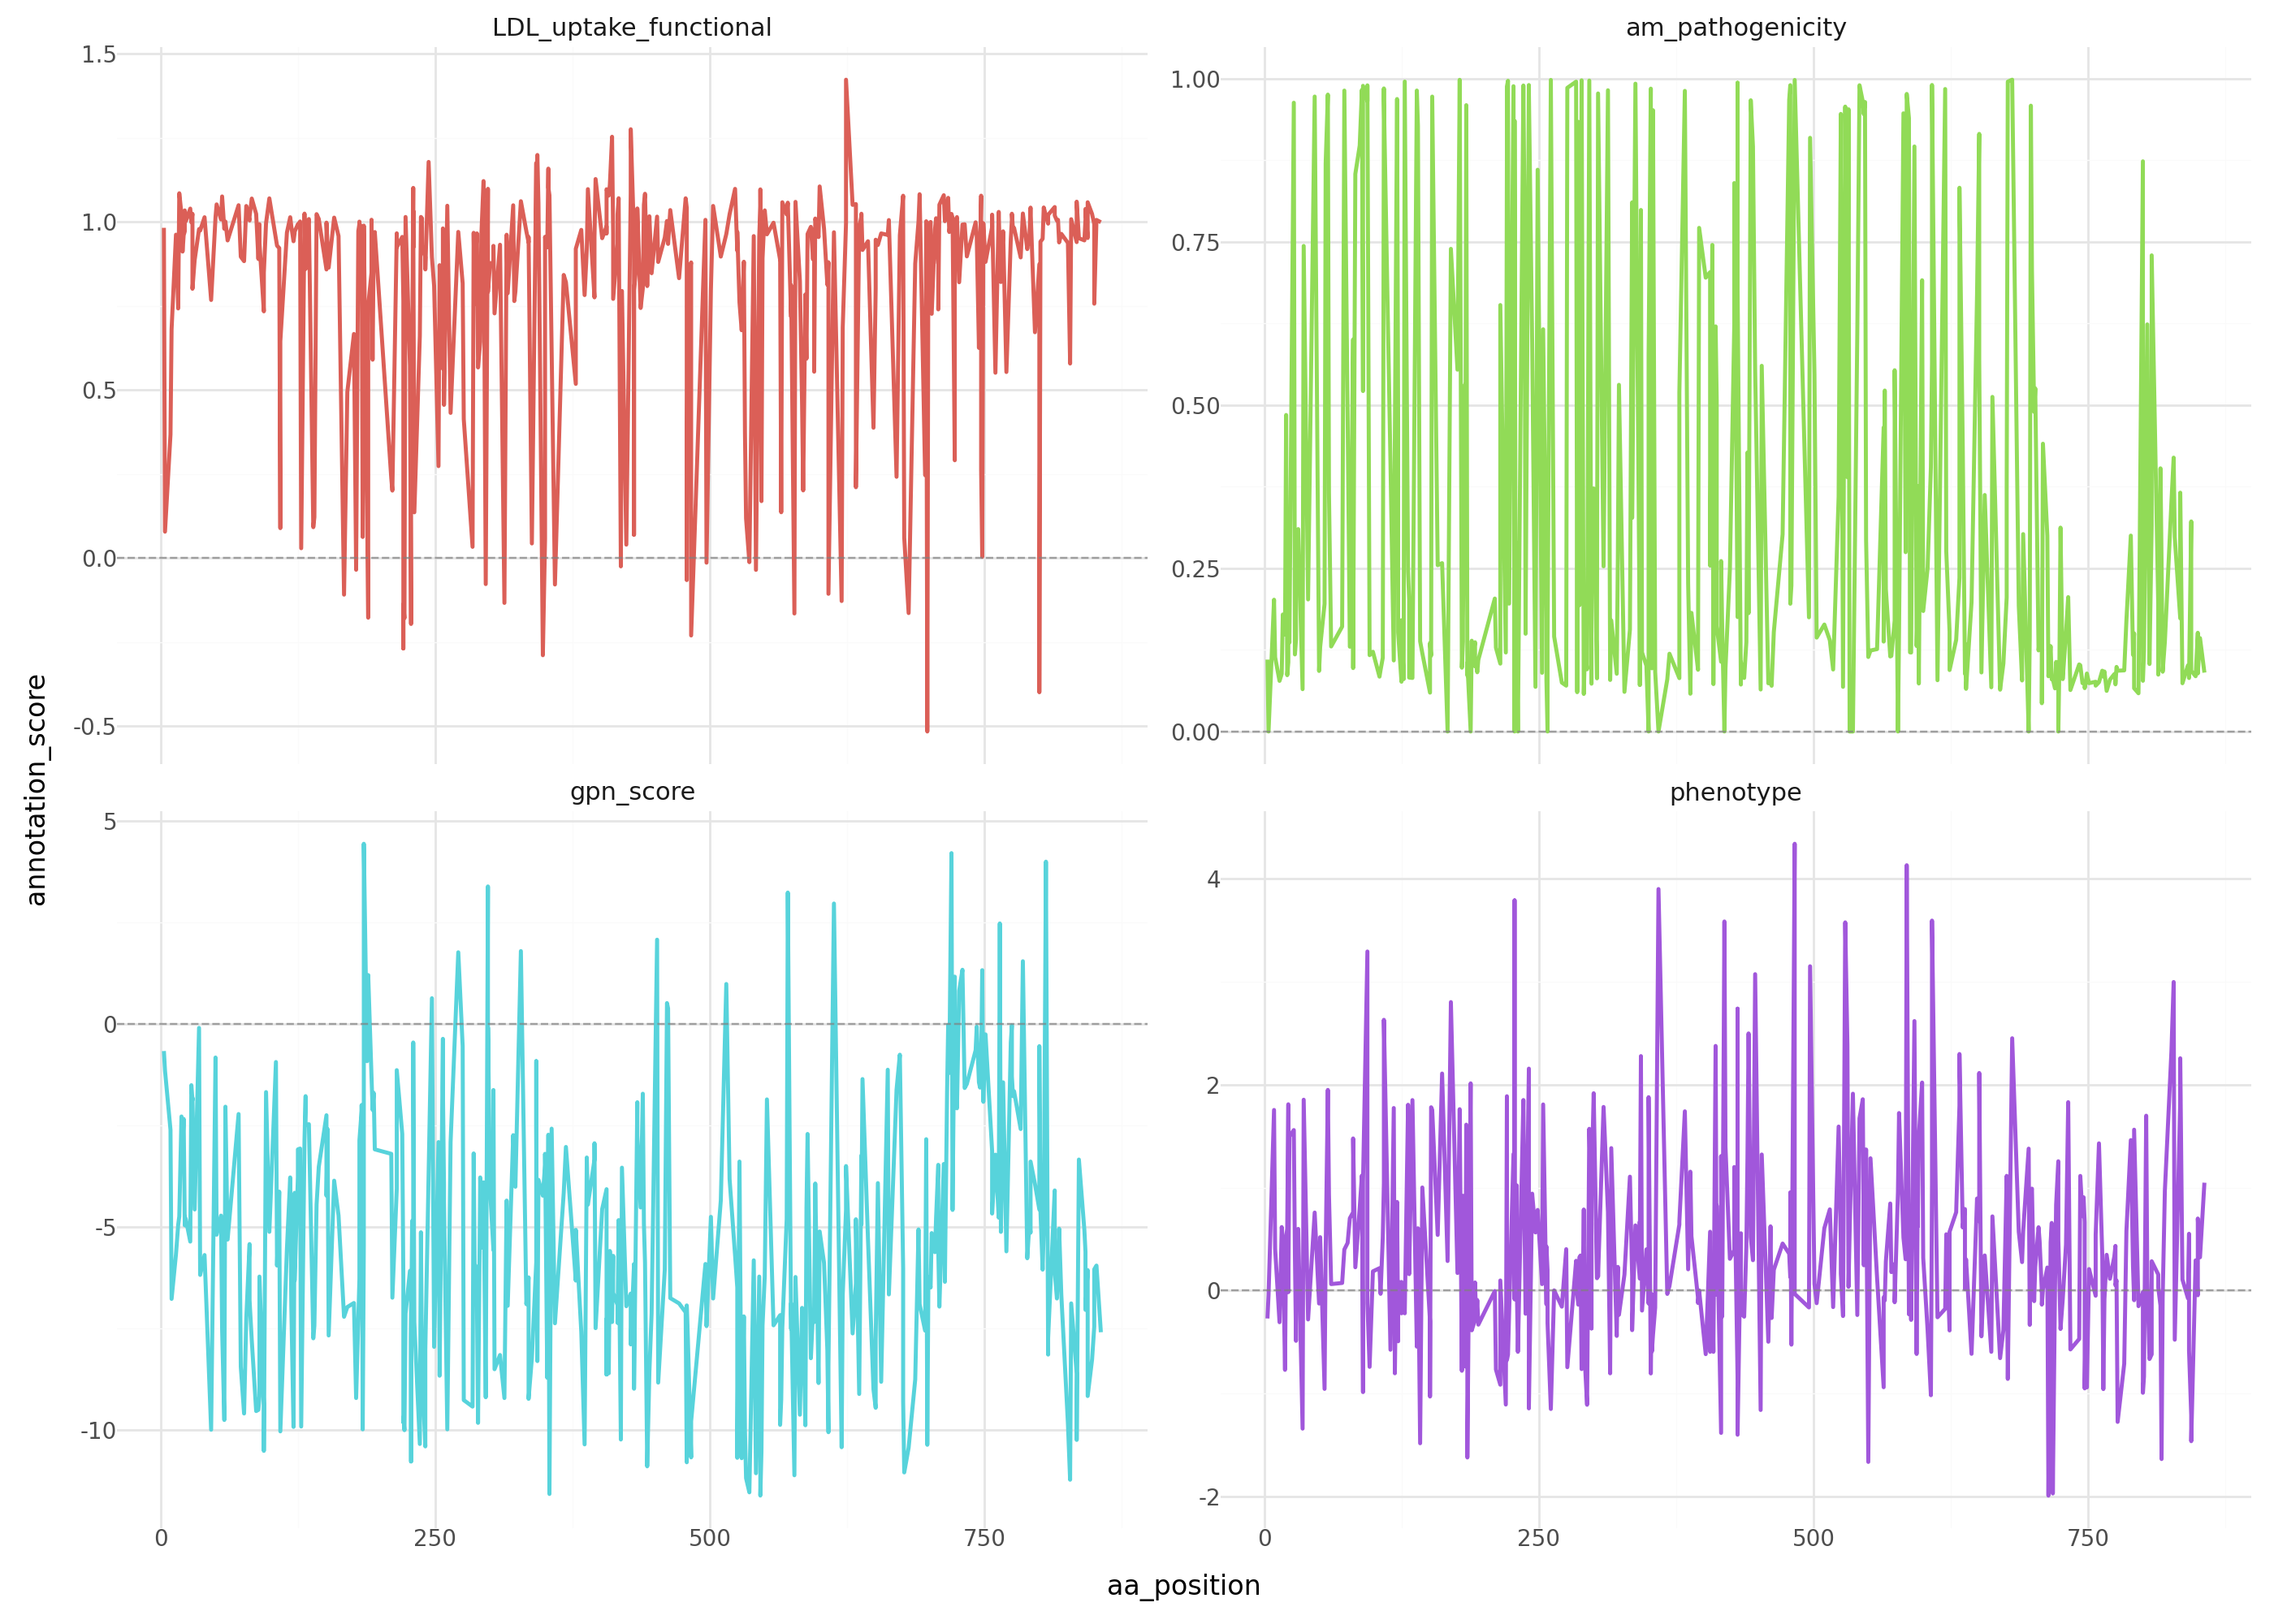

In [13]:
(
    ggplot(
        anno_df.filter(pl.col('annotation').is_in(['phenotype', assay2plot, 'am_pathogenicity', 'gpn_score'])), 
        aes(x='aa_position', y='annotation_score', color='annotation')
    )
    + geom_line(size=1)
    + geom_hline(yintercept=0, linetype='dashed', color='grey', alpha=0.7)
    + facet_wrap("~annotation", ncol=2, scales="free_y")
    + theme_minimal()
    + theme(
        figure_size=(14, 10),
        legend_position="none",
        axis_text=element_text(size=10),
        axis_title=element_text(size=12),
        strip_text=element_text(size=11),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [14]:
# Get variant ID to amino acid position mapping from the annotation parquet
anno_with_pos = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .filter(
        pl.col('amino_acids').is_not_null(),
        pl.col('amino_acids').str.contains("/"),
        ~pl.col('protein_position').str.contains("-"),
        pl.col('region').is_in(gene_trait_df['region'].unique()),
    )
    .with_columns(
        pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
    )
    .select(['id', 'aa_position'])
    .unique()
    .collect()
)

# Add position to pre_corr_data
pre_corr_pos = pre_corr_data.join(anno_with_pos, on='id', how='inner')
print(f"Variants with position: {pre_corr_pos['id'].n_unique()} / {pre_corr_data['id'].n_unique()}")
print(f"Position range: {pre_corr_pos['aa_position'].min()} - {pre_corr_pos['aa_position'].max()}")
pre_corr_pos

/tmp/ipykernel_470200/3176608207.py:15: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


Variants with position: 398 / 398
Position range: 3 - 856


id,phenotype,mean_pheno_value,n_individuals,region,annotation,annotation_score,aa_position
str,str,f32,i32,str,str,f32,i64
"""chr19:11102786:C:T""","""ldl_direct_int""",0.21773,4,"""ENSG00000130164""","""am_pathogenicity""",0.084,105
"""chr19:11129623:G:A""","""ldl_direct_int""",1.847051,1,"""ENSG00000130164""","""am_pathogenicity""",0.1733,834
"""chr19:11102786:C:T""","""ldl_direct_int""",0.21773,4,"""ENSG00000130164""","""esmscoremissense""",-4.135,105
"""chr19:11129623:G:A""","""ldl_direct_int""",1.847051,1,"""ENSG00000130164""","""esmscoremissense""",-10.071,834
"""chr19:11102786:C:T""","""ldl_direct_int""",0.21773,4,"""ENSG00000130164""","""gpn_score""",-0.94,105
…,…,…,…,…,…,…,…
"""chr19:11120488:G:A""","""ldl_direct_int""",0.230201,1,"""ENSG00000130164""","""gpn_score""",-5.15,702
"""chr19:11129534:T:C""","""ldl_direct_int""",0.124859,7,"""ENSG00000130164""","""gpn_score""",-5.07,804
"""chr19:11120488:G:A""","""ldl_direct_int""",0.230201,1,"""ENSG00000130164""","""verphylop""",7.84,702


In [15]:
from sklearn.linear_model import LinearRegression

def compute_running_r2(df, window_size=100, step_size=1, min_variants=15):
    """
    Fit a global linear regression per annotation (annotation_score → mean_pheno_value),
    then compute local R² in each sliding window as 1 - SS_res / SS_tot.
    
    R² > 0: global model explains local variance well
    R² ≈ 0: no better than predicting the local mean
    R² < 0: global model is *worse* than the local mean (relationship breaks down)
    """
    results = []

    for annotation in df['annotation'].unique():
        anno_df = df.filter(pl.col('annotation') == annotation).sort('aa_position')

        positions = anno_df['aa_position'].to_numpy()
        scores = anno_df['annotation_score'].to_numpy().astype(np.float64)
        pheno = anno_df['mean_pheno_value'].to_numpy().astype(np.float64)

        # Valid mask (no NaNs)
        valid = ~np.isnan(scores) & ~np.isnan(pheno)
        if valid.sum() < 2:
            continue

        # Fit global linear regression: annotation_score → mean_pheno_value
        X_global = scores[valid].reshape(-1, 1)
        y_global = pheno[valid]
        model = LinearRegression().fit(X_global, y_global)

        # Sliding window R²
        pos_min, pos_max = int(positions.min()), int(positions.max())
        half_w = window_size // 2

        for center in range(pos_min + half_w, pos_max - half_w + 1, step_size):
            lo, hi = center - half_w, center + half_w
            mask = (positions >= lo) & (positions <= hi) & valid
            n = mask.sum()

            if n >= min_variants:
                y_win = pheno[mask]
                y_pred = model.predict(scores[mask].reshape(-1, 1))
                ss_res = np.sum((y_win - y_pred) ** 2)
                ss_tot = np.sum((y_win - y_win.mean()) ** 2)
                r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

                results.append({
                    'annotation': annotation,
                    'center_position': center,
                    'window_start': lo,
                    'window_end': hi,
                    'n_variants': int(n),
                    'r_squared': r2,
                    'global_slope': model.coef_[0],
                    'global_intercept': model.intercept_,
                })

    return pl.DataFrame(results)

# Parameters — adjust as needed
window_size = 100   # amino acid positions wide
step_size = 1       # slide by 1 position
min_variants = 15   # minimum variants per window

running_corr = compute_running_r2(
    pre_corr_pos,
    window_size=window_size,
    step_size=step_size,
    min_variants=min_variants,
)

# Join with annotation metadata for plotting
running_corr = (
    running_corr
    .join(anno_config_df.select(['annotation', 'label', 'color']), on='annotation')
)

print(f"Running R² results: {running_corr.shape}")
print(f"Annotations: {running_corr['annotation'].unique().to_list()}")
running_corr

Running R² results: (6032, 10)
Annotations: ['cadd_raw', 'am_pathogenicity', 'gpn_score', 'LDLR_cell_surface_abundance', 'score_pai3d', 'LDL_uptake_functional', 'verphylop', 'esmscoremissense']


annotation,center_position,window_start,window_end,n_variants,r_squared,global_slope,global_intercept,label,color
str,i64,i64,i64,i64,f64,f64,f64,str,str
"""am_pathogenicity""",53,3,103,44,0.144265,0.80222,0.142165,"""AlphaMissense""","""#feb72d"""
"""am_pathogenicity""",54,4,104,43,0.137108,0.80222,0.142165,"""AlphaMissense""","""#feb72d"""
"""am_pathogenicity""",55,5,105,43,0.132617,0.80222,0.142165,"""AlphaMissense""","""#feb72d"""
"""am_pathogenicity""",56,6,106,44,0.137932,0.80222,0.142165,"""AlphaMissense""","""#feb72d"""
"""am_pathogenicity""",57,7,107,44,0.137932,0.80222,0.142165,"""AlphaMissense""","""#feb72d"""
…,…,…,…,…,…,…,…,…,…
"""cadd_raw""",802,752,852,49,0.067402,0.145003,0.000319,"""CADD Raw""","""#1f77b4"""
"""cadd_raw""",803,753,853,49,0.067402,0.145003,0.000319,"""CADD Raw""","""#1f77b4"""
"""cadd_raw""",804,754,854,49,0.067402,0.145003,0.000319,"""CADD Raw""","""#1f77b4"""


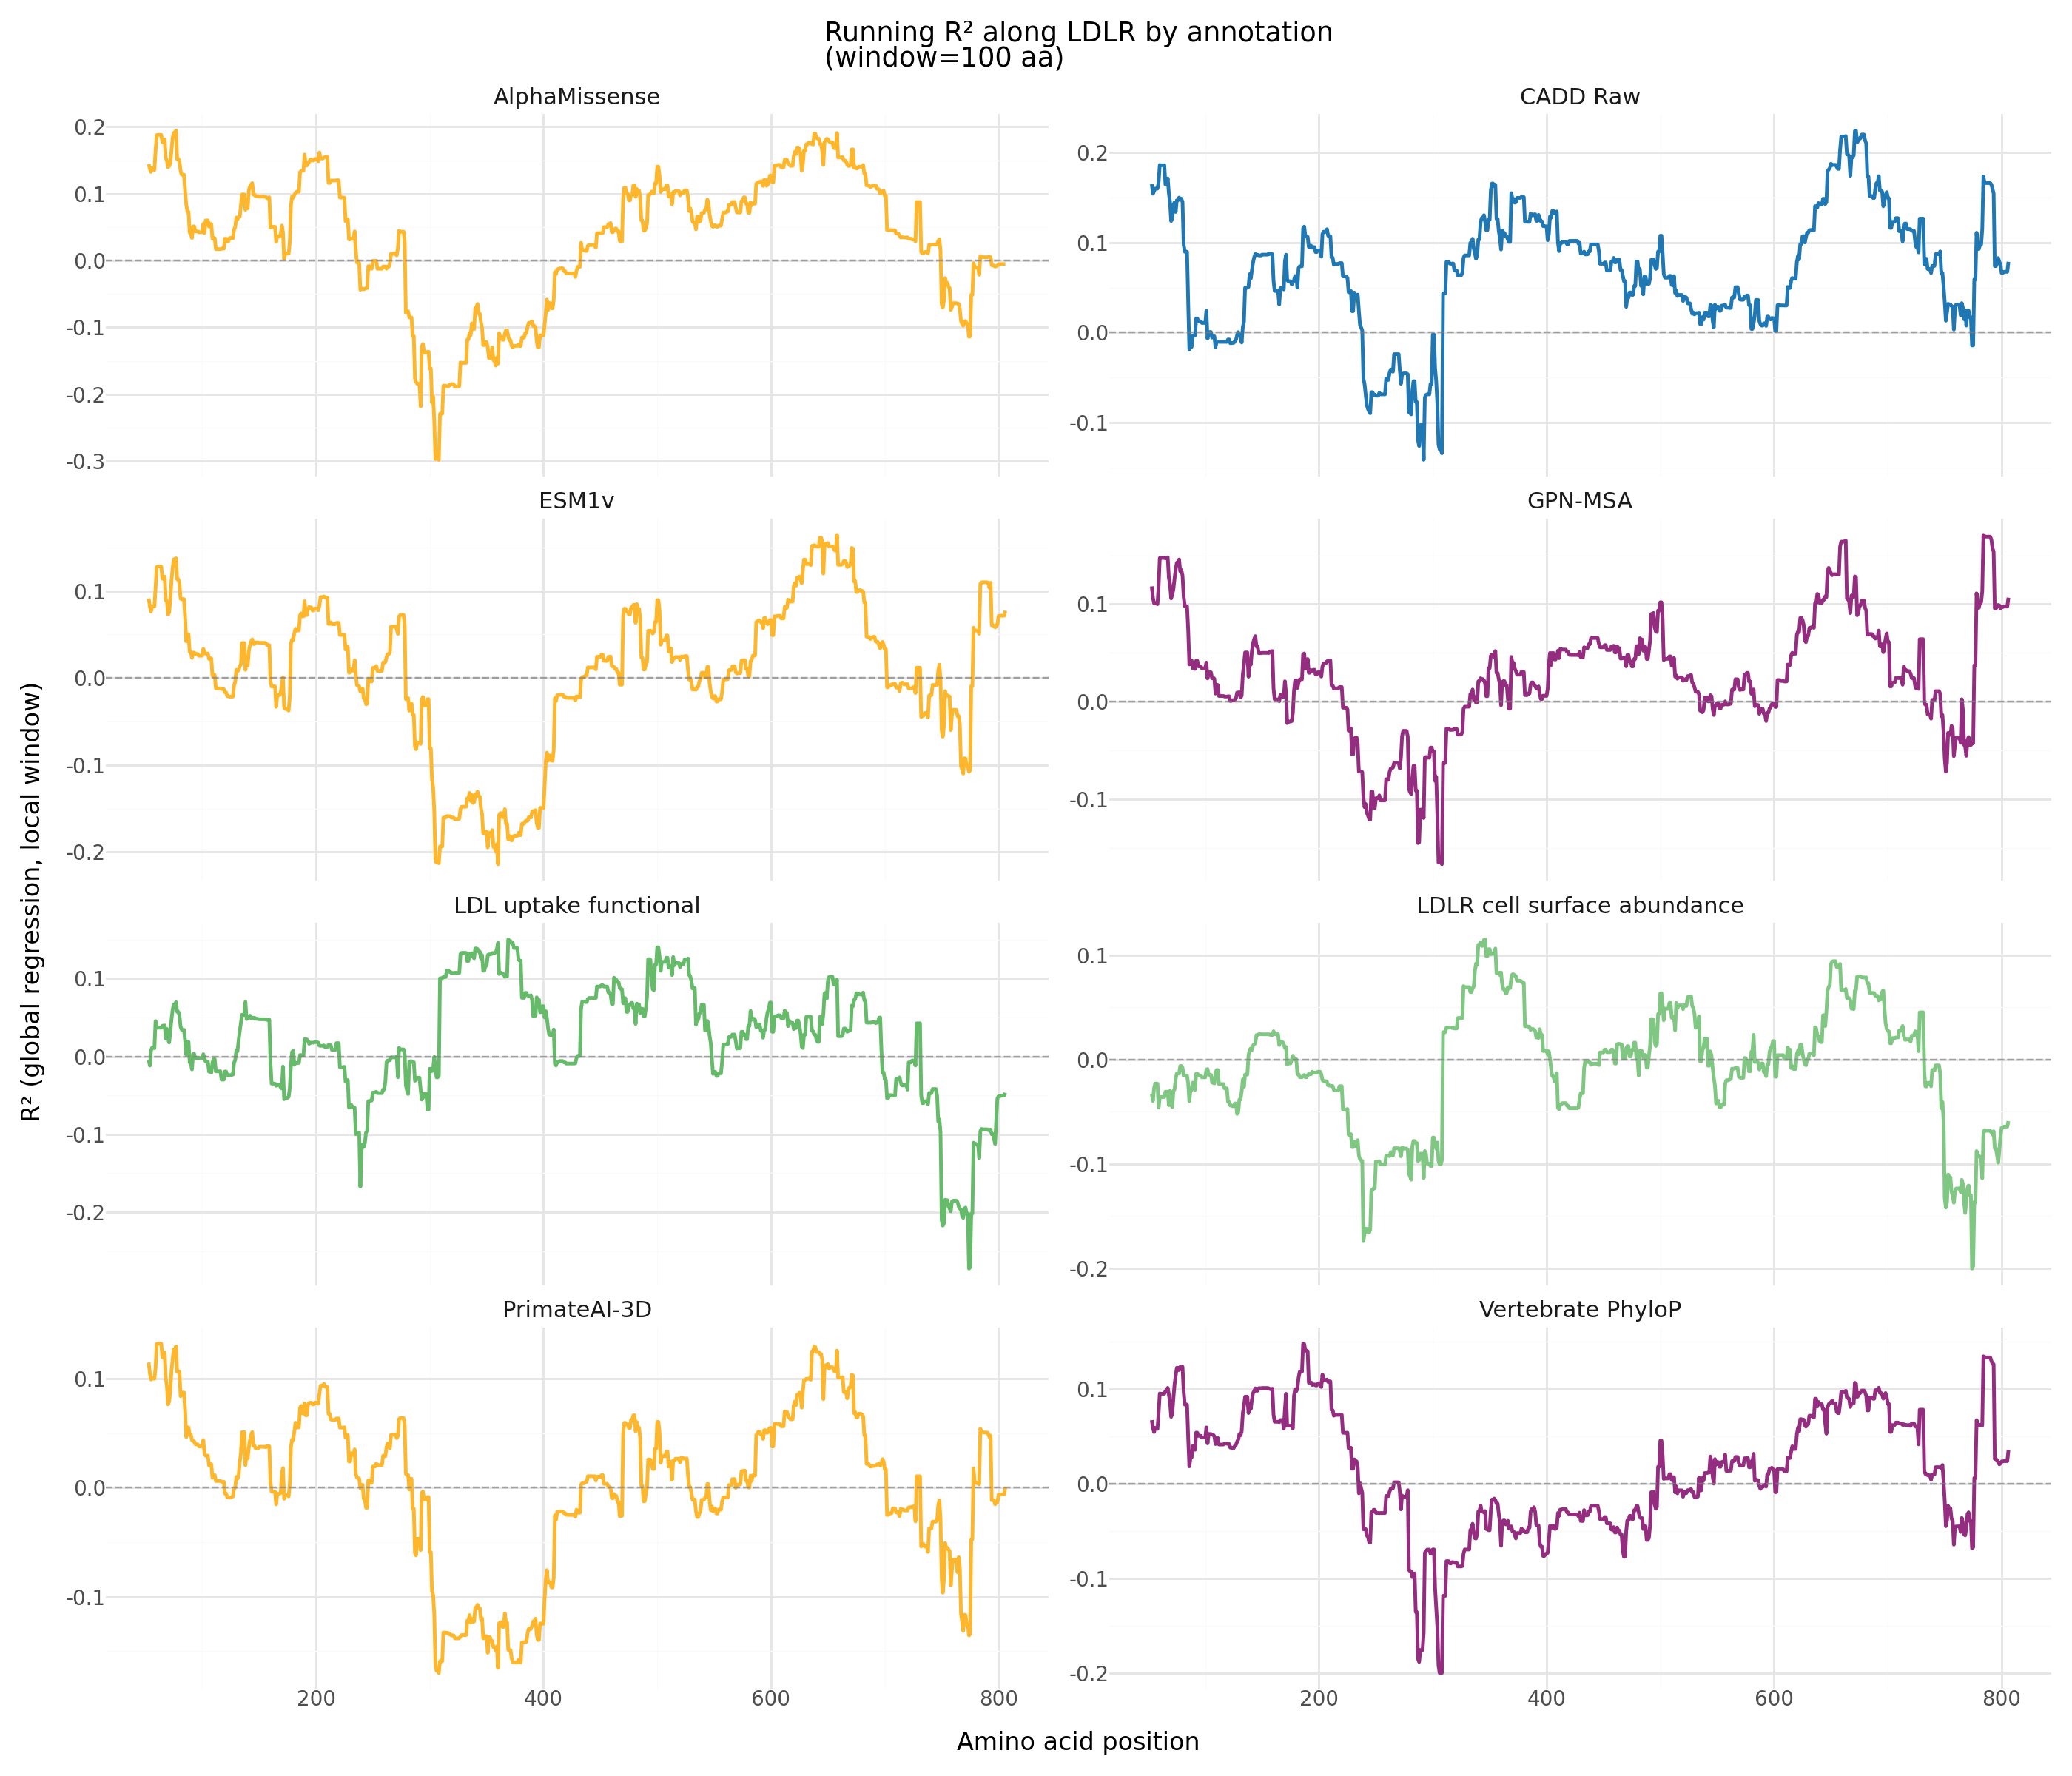

In [16]:
color_dict = dict(running_corr.select("label", "color").unique().iter_rows())

# Faceted plot: one panel per annotation for cleaner comparison
(
    ggplot(running_corr, aes(x="center_position", y="r_squared", color="label"))
    + geom_line(size=1)
    + geom_hline(yintercept=0, linetype='dashed', color='grey', alpha=0.7)
    + facet_wrap("~label", ncol=2, scales="free_y")
    + theme_minimal()
    + scale_color_manual(values=color_dict)
    + labs(
        x="Amino acid position",
        y="R² (global regression, local window)",
        title=f"Running R² along LDLR by annotation\n(window={window_size} aa)",
    )
    + theme(
        figure_size=(14, 3 * ((running_corr['label'].n_unique() + 1) // 2)),
        legend_position="none",
        axis_text=element_text(size=10),
        axis_title=element_text(size=12),
        strip_text=element_text(size=11),
        plot_background=element_rect(fill="white", color="white"),
    )
)

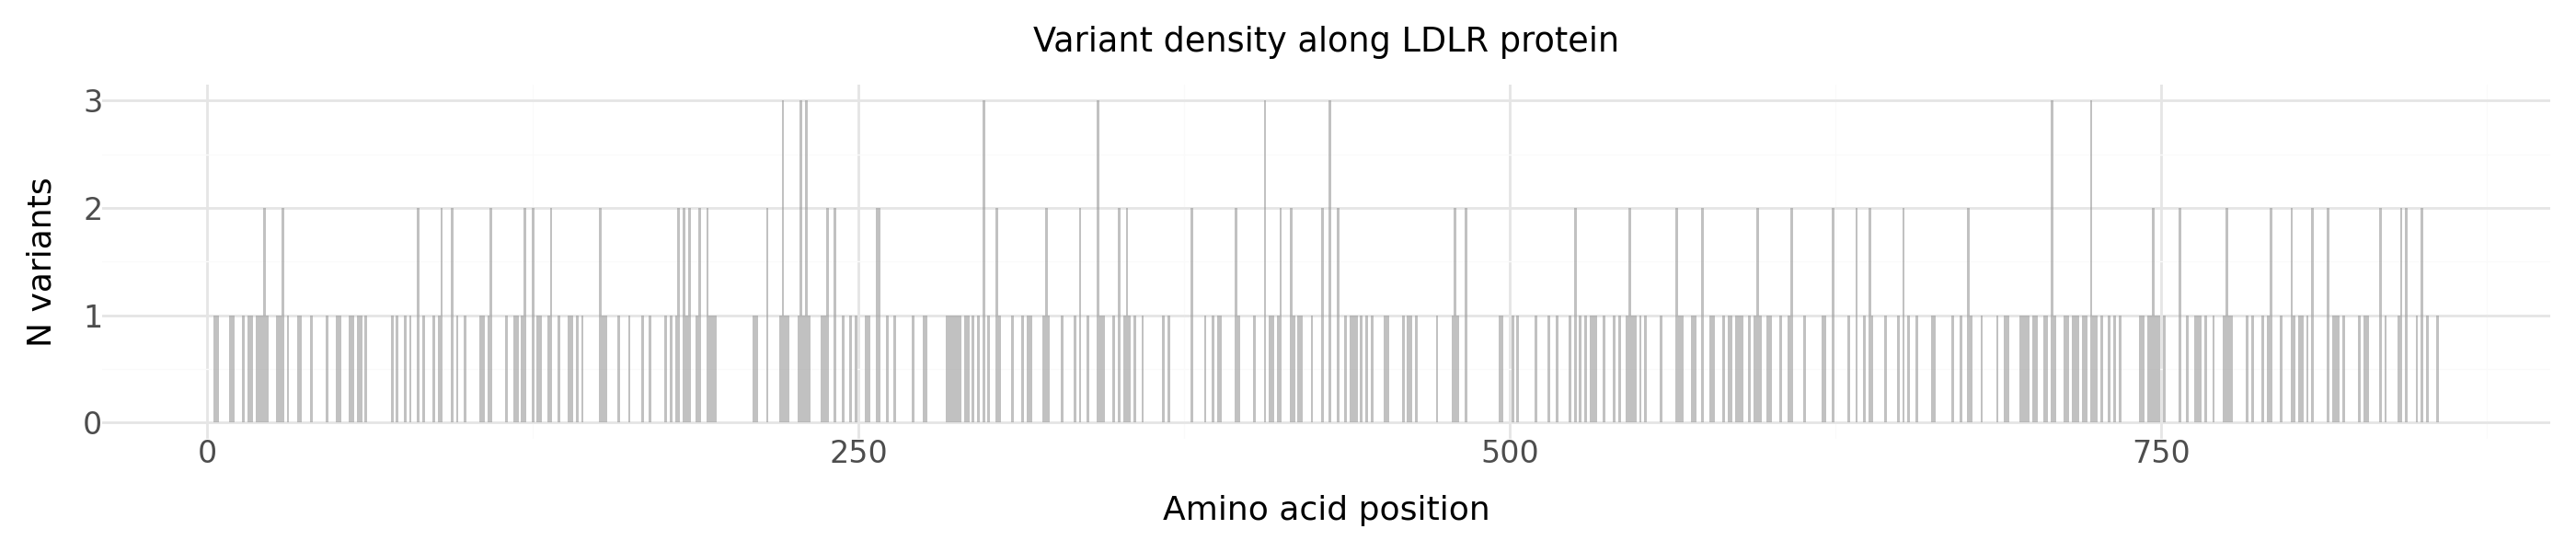

In [17]:
# Variant density along the protein (useful context for interpreting correlation dips)
# Uses the same pre_corr_pos data, taking one annotation to count unique variants per position
variant_positions = (
    pre_corr_pos
    .select(['id', 'aa_position'])
    .unique()
    .group_by('aa_position')
    .agg(n_variants=pl.len())
    .sort('aa_position')
)

(
    ggplot(variant_positions, aes(x="aa_position", y="n_variants"))
    + geom_col(fill="#999999", alpha=0.6, width=1)
    + theme_minimal()
    + labs(
        x="Amino acid position",
        y="N variants",
        title="Variant density along LDLR protein",
    )
    + theme(
        figure_size=(14, 3),
        axis_text=element_text(size=12),
        axis_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [18]:
# Extract domain annotations per amino acid position
domain_cols = ['mobi_curated_disorder_priority', 'mobi_lip_full', 'ted_domain', 'low_complexity_domain']

domain_df = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .filter(
        pl.col('amino_acids').is_not_null(),
        pl.col('amino_acids').str.contains("/"),
        ~pl.col('protein_position').str.contains("-"),
        pl.col('region').is_in(gene_trait_df['region'].unique()),
    )
    .with_columns(
        pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
    )
    .select(['aa_position'] + domain_cols)
    .group_by('aa_position')
    .agg([pl.col(c).max().alias(c) for c in domain_cols])  # any True at this position
    .sort('aa_position')
    .collect()
)

# Build contiguous domain intervals for plotting as horizontal bars
domain_labels = {
    'ted_domain': 'Structured Domain (TED)',
    'mobi_curated_disorder_priority': 'Disordered Region',
    'mobi_lip_full': 'Linear Interacting Peptide',
    'low_complexity_domain': 'Low Complexity',
}
domain_colors = {
    'ted_domain': '#2E8B57',
    'mobi_curated_disorder_priority': '#E31A1C',
    'mobi_lip_full': '#1E90FF',
    'low_complexity_domain': '#FF9933',
}

def get_intervals(positions, values):
    """Return list of (start, end) intervals where values are True."""
    intervals = []
    in_region = False
    for pos, val in zip(positions, values):
        if val and not in_region:
            start = pos
            in_region = True
        elif not val and in_region:
            intervals.append((start, prev_pos))
            in_region = False
        prev_pos = pos
    if in_region:
        intervals.append((start, prev_pos))
    return intervals

domain_intervals = {}
positions = domain_df['aa_position'].to_numpy()
for col in domain_cols:
    vals = domain_df[col].to_numpy().astype(bool)
    domain_intervals[col] = get_intervals(positions, vals)

print("Domain intervals:")
for col, intervals in domain_intervals.items():
    print(f"  {domain_labels[col]}: {intervals}")

/tmp/ipykernel_470200/3434779060.py:19: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


Domain intervals:
  Disordered Region: [(np.int64(4), np.int64(275)), (np.int64(354), np.int64(389)), (np.int64(714), np.int64(787))]
  Linear Interacting Peptide: [(np.int64(9), np.int64(16)), (np.int64(46), np.int64(62)), (np.int64(81), np.int64(106)), (np.int64(119), np.int64(144)), (np.int64(162), np.int64(184)), (np.int64(213), np.int64(231)), (np.int64(253), np.int64(271)), (np.int64(314), np.int64(344)), (np.int64(358), np.int64(362)), (np.int64(399), np.int64(399)), (np.int64(663), np.int64(663)), (np.int64(705), np.int64(705)), (np.int64(720), np.int64(725)), (np.int64(730), np.int64(732)), (np.int64(753), np.int64(770)), (np.int64(783), np.int64(829))]
  Structured Domain (TED): [(np.int64(210), np.int64(249)), (np.int64(284), np.int64(335)), (np.int64(399), np.int64(653))]
  Low Complexity: [(np.int64(791), np.int64(808))]


In [19]:
running_corr['annotation'].unique()

annotation
str
"""verphylop"""
"""LDLR_cell_surface_abundance"""
"""esmscoremissense"""
"""LDL_uptake_functional"""
"""cadd_raw"""
"""am_pathogenicity"""
"""gpn_score"""
"""score_pai3d"""


/tmp/ipykernel_470200/949375266.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


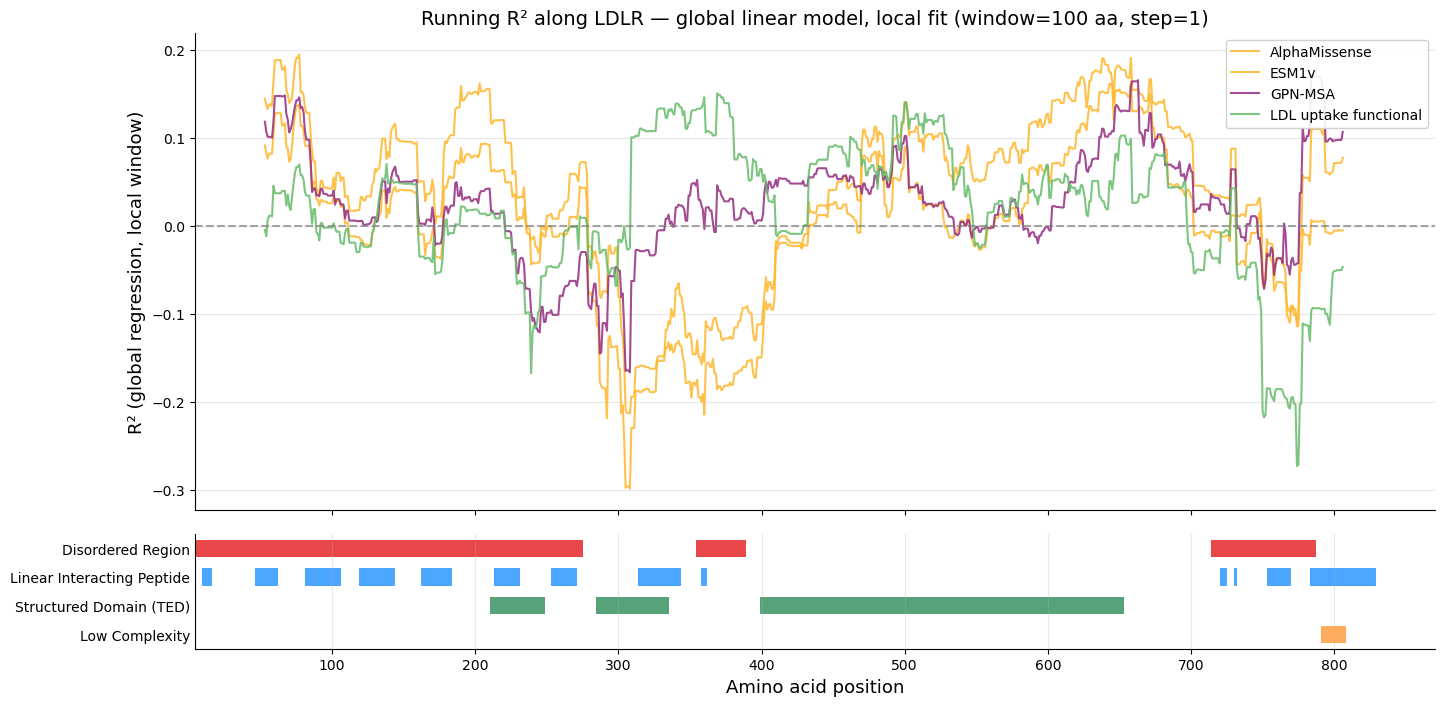

In [21]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec


annos2plot = ['am_pathogenicity', 'esmscoremissense', 'gpn_score', assay2plot]
running_corr_plot = (
    running_corr
    .filter(pl.col('annotation').is_in(annos2plot))
)

# Build the combined figure: running R² + domain track
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(2, 1, height_ratios=[5, 1.2], hspace=0.08)

ax_corr = fig.add_subplot(gs[0])
ax_dom = fig.add_subplot(gs[1], sharex=ax_corr)

# --- Top panel: running R² ---
color_dict_label = dict(running_corr_plot.select("label", "color").unique().iter_rows())

for label in running_corr_plot['label'].unique().sort():
    sub = (
        running_corr_plot
        .filter(pl.col('label') == label)
        .sort('center_position')
    )
    ax_corr.plot(
        sub['center_position'].to_numpy(),
        sub['r_squared'].to_numpy(),
        label=label,
        color=color_dict_label[label],
        linewidth=1.5,
        alpha=0.85,
    )

ax_corr.axhline(0, color='grey', linestyle='--', alpha=0.7)
ax_corr.set_ylabel("R² (global regression, local window)", fontsize=13)
ax_corr.set_title(
    f"Running R² along LDLR — global linear model, local fit (window={window_size} aa, step={step_size})",
    fontsize=14,
)
ax_corr.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax_corr.tick_params(axis='x', labelbottom=False)
ax_corr.grid(axis='y', alpha=0.3)

# --- Bottom panel: domain track ---
track_height = 0.6
active_domains = [col for col in domain_cols if len(domain_intervals[col]) > 0]

for i, col in enumerate(active_domains):
    y_center = i
    for start, end in domain_intervals[col]:
        ax_dom.barh(
            y_center, end - start, left=start,
            height=track_height,
            color=domain_colors[col],
            edgecolor='none',
            alpha=0.8,
        )

ax_dom.set_yticks(range(len(active_domains)))
ax_dom.set_yticklabels([domain_labels[c] for c in active_domains], fontsize=10)
ax_dom.set_xlabel("Amino acid position", fontsize=13)
ax_dom.set_ylim(-0.5, len(active_domains) - 0.5)
ax_dom.invert_yaxis()
ax_dom.tick_params(axis='y', length=0)
ax_dom.grid(axis='x', alpha=0.3)

# Clean up spines
for ax in [ax_corr, ax_dom]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()